In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from dataset import Multi30kDataset
from model import Transformer, make_src_mask, make_tgt_mask

from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu

from dataset import *
from lr_scheduler import *
from model import *

import wandb


In [2]:
language_dataset = Multi30kDataset(split = "train")
config = {
        "src_vocab_size"   : len(language_dataset.de_vocab),
        "tgt_vocab_size"   : len(language_dataset.en_vocab),
        "d_model"          : 512,
        "N"                : 6,
        "num_heads"        : 8,
        "d_ff"             : 2048,
        "dropout"          : 0.1,
        "train_batch_size" : 32,
        "test_batch_size"  : 32,
        "epochs"           : 15,
        "device"           : "cpu",
        'save_every'       : 4
    }

processed_dataset = language_dataset.process_data()
train_dataset_obj = TranslationDataset(processed_dataset)
train_dataloader = DataLoader(
    train_dataset_obj,
    batch_size=config["train_batch_size"],
    shuffle=True,
    collate_fn=collate_fn
)

Building vocab, please wait...


100%|██████████| 29000/29000 [00:00<00:00, 35989.30it/s]


In [3]:
transformer = Transformer(src_vocab_size = config["src_vocab_size"], tgt_vocab_size = config['tgt_vocab_size'],
                            d_model = 512, N = 6, num_heads = 8, d_ff = 2048,
                            dropout = 0.1).to(config["device"])

In [4]:
load_checkpoint("checkpoint.pt", transformer)

14

In [5]:
src = next(iter(train_dataloader))[0]
tgt = next(iter(train_dataloader))[1]


tgt_input = tgt[:, :-1]
tgt_output = tgt[:, 1:]

tgt_mask = make_tgt_mask(tgt_input)
src_mask = make_src_mask(src)

In [6]:
logits = transformer(src, tgt_input, src_mask, tgt_mask)

In [7]:
# encoder self attn
encoder_self_attn = transformer.encoder.encoder_layers[-1].mha_self_attn.attn_weights

# decoder masked self attn
decoder_masked_self_attn = transformer.decoder.decoder_layers[-1].self_attn.attn_weights

# decoder cross attn
decoder_cross_attn = transformer.decoder.decoder_layers[-1].cross_attn.attn_weights

In [8]:
decoder_masked_self_attn.shape

torch.Size([32, 8, 28, 28])

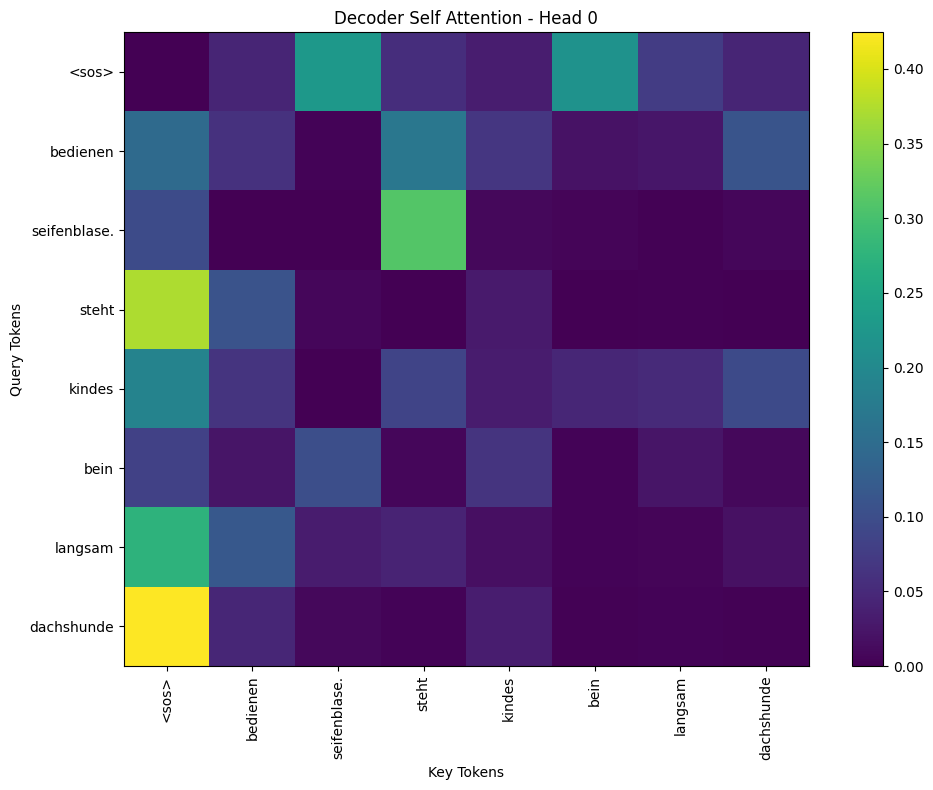

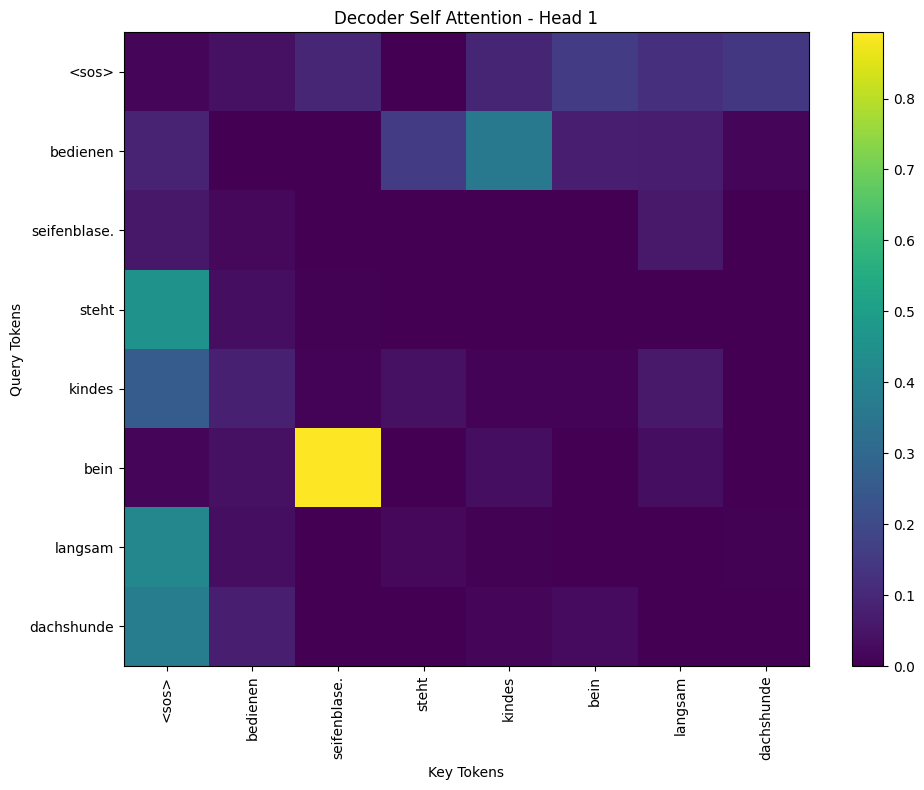

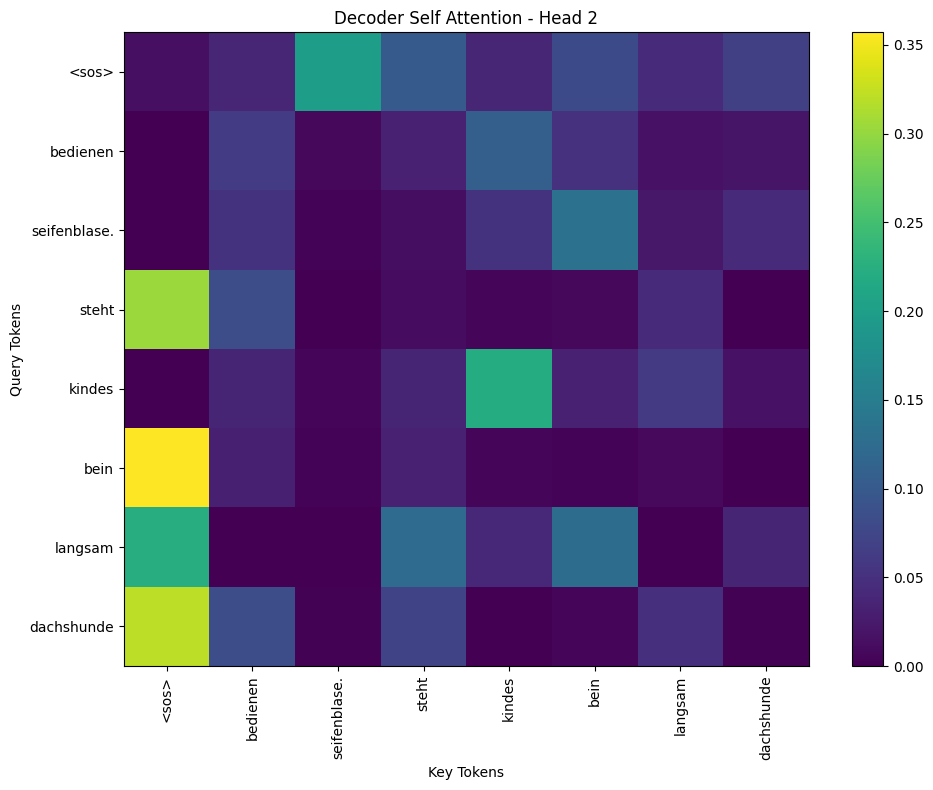

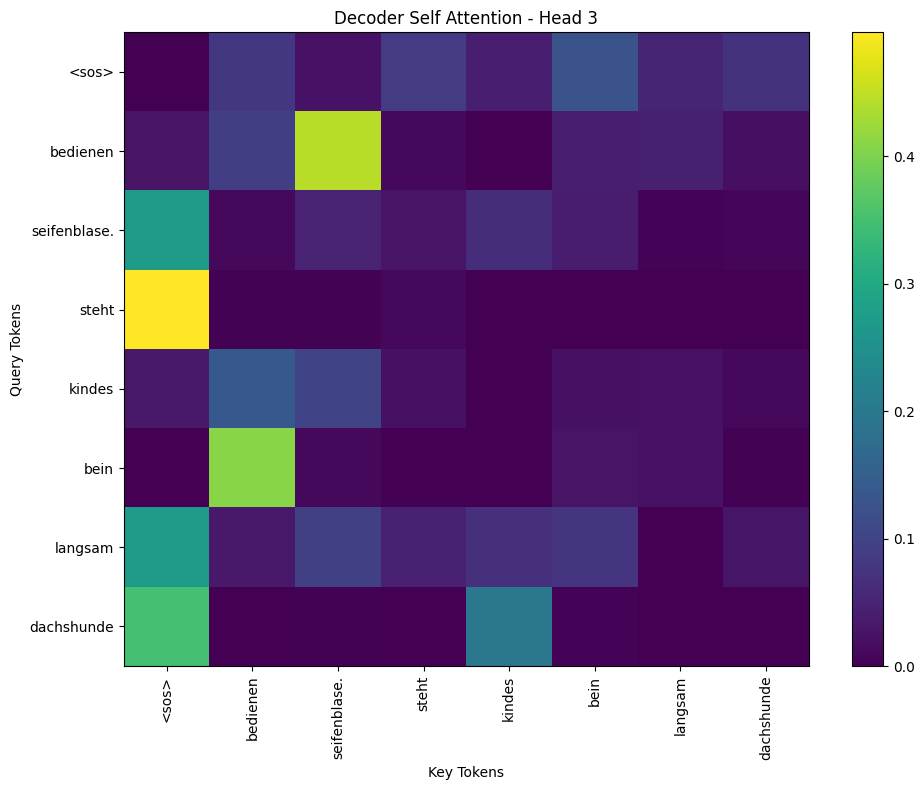

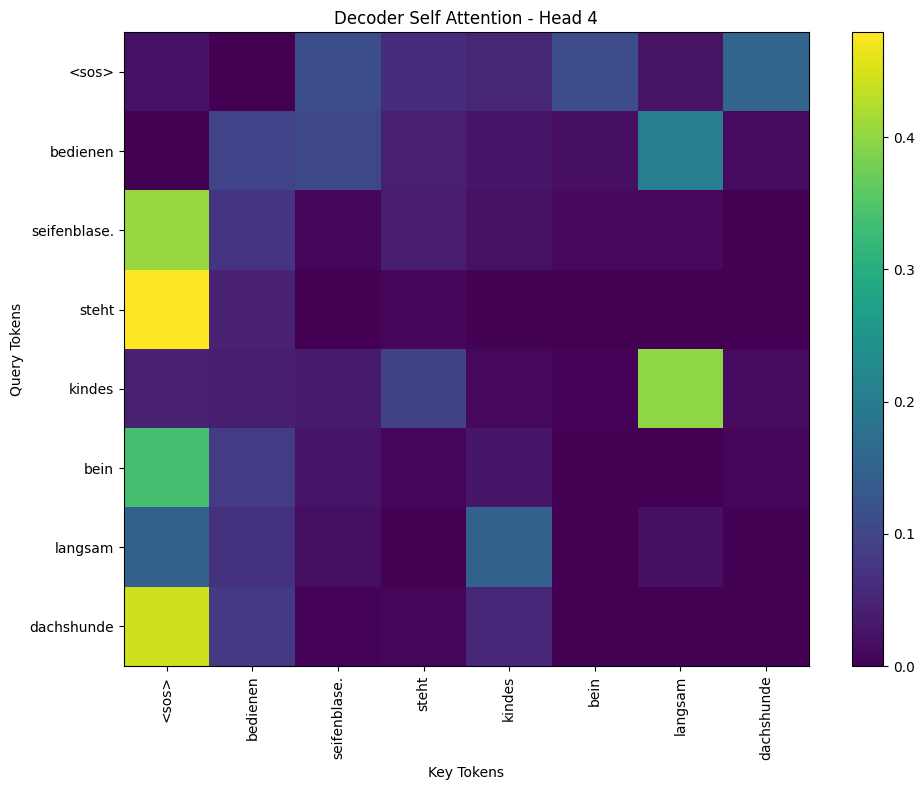

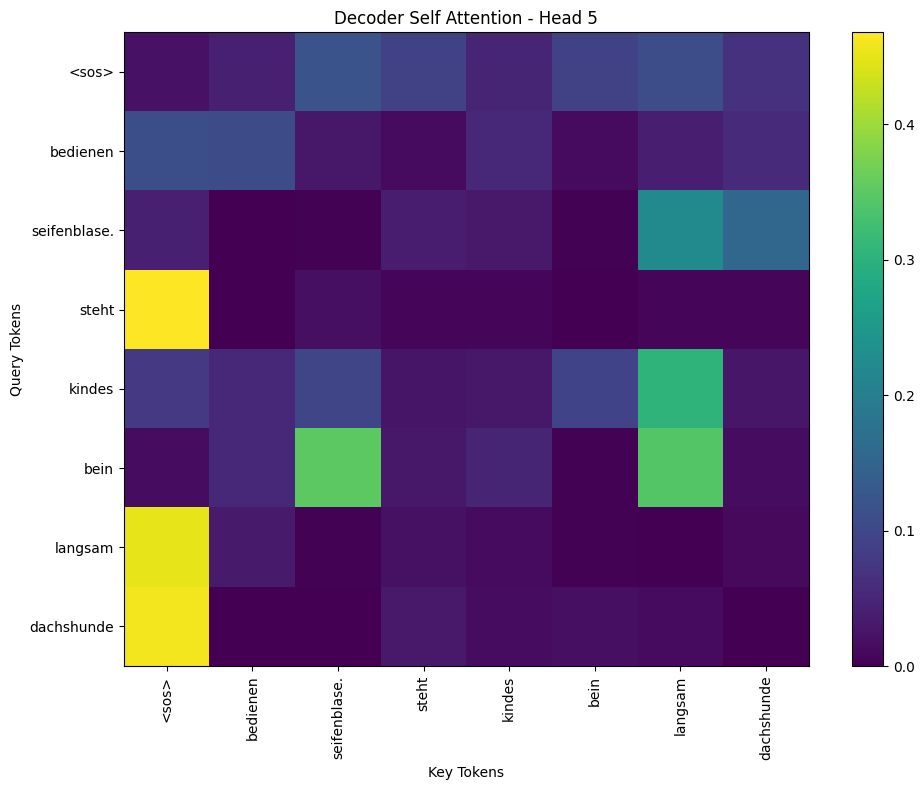

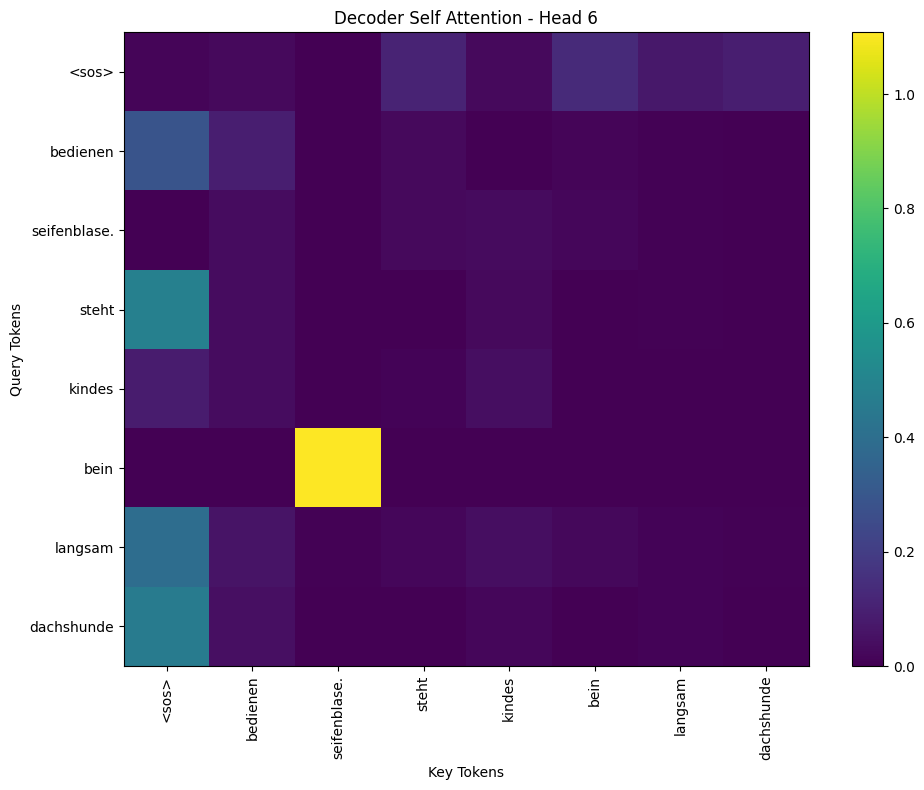

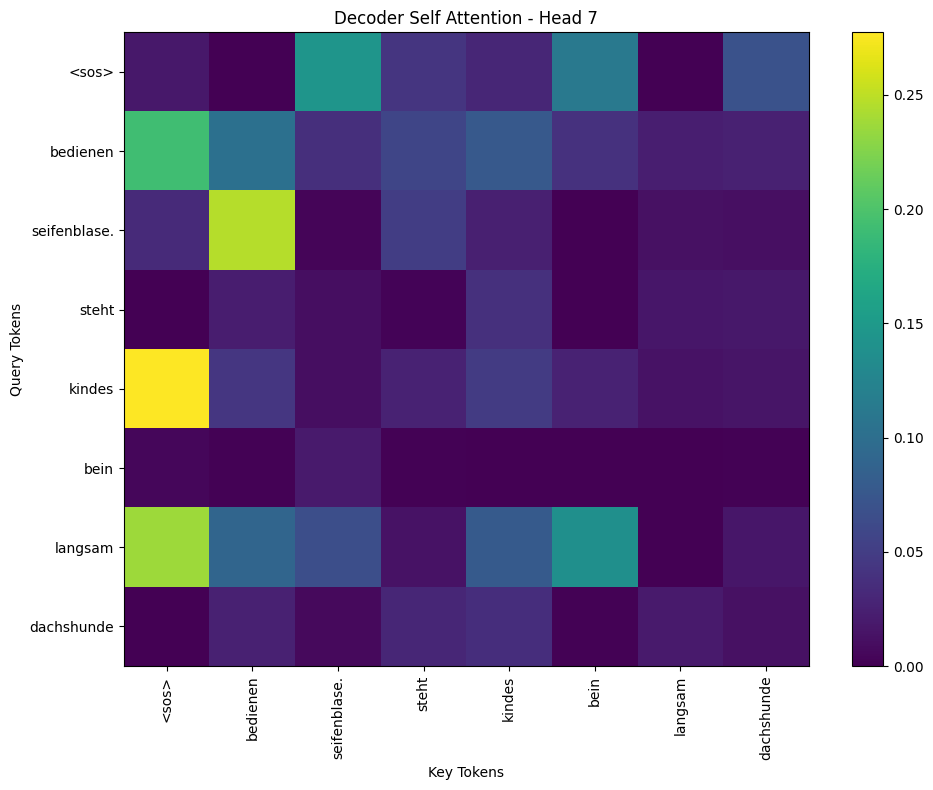

In [9]:
sample = 3
head = 0
for head in range(8):
    # attention map
    heatmap = encoder_self_attn[sample, head].detach().cpu()

    # token ids
    tokens = tgt_input[sample].detach().cpu().tolist()

    # convert ids -> words
    words = []

    for tok in tokens:

        # word = language_dataset.en_itos[tok]
        word = language_dataset.de_itos[tok]

        # stop at eos if you want
        if word == "<eos>":
            break

        words.append(word)

    # crop heatmap to actual sentence length
    heatmap = heatmap[:len(words), :len(words)]

    plt.figure(figsize=(10, 8))

    plt.imshow(heatmap, aspect='auto')

    plt.xticks(range(len(words)), words, rotation=90)
    plt.yticks(range(len(words)), words)

    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")

    plt.title(f"Decoder Self Attention - Head {head}")

    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [10]:
wandb.init()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/mohamedmafaz/.netrc.
wandb: Currently logged in as: mohdmafaz200303 (mafaz03) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


In [11]:
sample = 3

for head in range(8):

    heatmap = encoder_self_attn[sample, head].detach().cpu().numpy()

    tokens = tgt_input[sample].detach().cpu().tolist()

    words = []

    for tok in tokens:

        # word = language_dataset.en_itos[tok]
        word = language_dataset.de_itos[tok]

        if word == "<eos>":
            break

        words.append(word)

    heatmap = heatmap[:len(words), :len(words)]

    # create table
    data = []

    for i in range(len(words)):
        for j in range(len(words)):

            data.append([
                words[j],          # x
                words[i],          # y
                float(heatmap[i,j])
            ])

    table = wandb.Table(
        data=data,
        columns=["Key", "Query", "Attention"]
    )

    wandb.log({
        f"attention_table/head_{head}": table
    })